In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# df = pd.read_csv(path_folder + files[0])
df = pd.read_csv('preprocessing_data.csv')
df.head()

,Unnamed: 0,Headline,Tanggal,Link,Isi Berita,teks_gabung,data_clean,data_stopword,data_lemma,data_token,detokenization
0,0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,https://news.detik.com/berita/d-8287136/7-capa...,Kepolisian Daerah (Polda) Metro Jaya menutup t...,7 Capaian Polda Metro Sepanjang 2025. Kepolisi...,capaian polda metro sepanjang kepolisian daera...,capaian polda metro kepolisian daerah polda me...,capai polda metro polisi daerah polda metro ja...,"['capai', 'polda', 'metro', 'polisi', 'daerah'...",capai polda metro polisi daerah polda metro ja...
1,1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,https://finance.detik.com/infrastruktur/d-8287...,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,Gibran Angkat Bicara soal Pembangunan IKN. Pem...,gibran angkat bicara soal pembangunan ikn pemb...,gibran angkat bicara pembangunan ikn pembangun...,gibran angkat bicara bangun ikn bangun kota nu...,"['gibran', 'angkat', 'bicara', 'bangun', 'ikn'...",gibran angkat bicara bangun ikn bangun kota nu...
2,2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,https://www.detik.com/bali/wisata/d-8287190/ku...,Kunjungan wisatawan mancanegara ke Bali meleji...,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",kunjungan wisman ke bali melejit saat nataru t...,kunjungan wisman bali melejit nataru turis aus...,kunjung wisman bal lejit nataru turis australi...,"['kunjung', 'wisman', 'bal', 'lejit', 'nataru'...",kunjung wisman bal lejit nataru turis australi...
3,3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,https://news.detik.com/dw/d-8288417/china-tega...,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...","China Tegaskan Niat Reunifikasi, Taiwan Bertek...",china tegaskan niat reunifikasi taiwan berteka...,china tegaskan niat reunifikasi taiwan berteka...,china tegas niat reunifikasi taiwan tekad merd...,"['china', 'tegas', 'niat', 'reunifikasi', 'tai...",china tegas niat reunifikasi taiwan tekad merd...
4,4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,https://news.detik.com/kolom/d-8288430/kehadir...,Kehadiran Presiden Prabowo Subianto di lokasi ...,Kehadiran Negara dan Efektivitas Penanganan Be...,kehadiran negara dan efektivitas penanganan be...,kehadiran negara efektivitas penanganan bencan...,hadir negara efektivitas tangan bencana hadir ...,"['hadir', 'negara', 'efektivitas', 'tangan', '...",hadir negara efektivitas tangan bencana hadir ...


In [ ]:
df.drop(columns=['Unnamed: 0','Link','data_stopword','data_lemma','data_token'], inplace=True, errors='ignore')

print(df.columns)

Index(['Headline', 'Tanggal', 'Isi Berita', 'teks_gabung', 'data_clean',
       'detokenization'],
      dtype='object')


In [ ]:
df.head()

,Headline,Tanggal,Isi Berita,teks_gabung,data_clean,detokenization
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,Kepolisian Daerah (Polda) Metro Jaya menutup t...,7 Capaian Polda Metro Sepanjang 2025. Kepolisi...,capaian polda metro sepanjang kepolisian daera...,capai polda metro polisi daerah polda metro ja...
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,Gibran Angkat Bicara soal Pembangunan IKN. Pem...,gibran angkat bicara soal pembangunan ikn pemb...,gibran angkat bicara bangun ikn bangun kota nu...
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,Kunjungan wisatawan mancanegara ke Bali meleji...,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",kunjungan wisman ke bali melejit saat nataru t...,kunjung wisman bal lejit nataru turis australi...
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...","China Tegaskan Niat Reunifikasi, Taiwan Bertek...",china tegaskan niat reunifikasi taiwan berteka...,china tegas niat reunifikasi taiwan tekad merd...
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,Kehadiran Presiden Prabowo Subianto di lokasi ...,Kehadiran Negara dan Efektivitas Penanganan Be...,kehadiran negara dan efektivitas penanganan be...,hadir negara efektivitas tangan bencana hadir ...


#Membaca Sentimen dari Isi Berita (data_clean)

In [ ]:
import pandas as pd
from transformers import pipeline
import os

# 1. Load Model
model_checkpoint = "mmhhz/model-indobert"
classifier = pipeline("text-classification", model=model_checkpoint)

def get_sentiment_details(teks):
    if pd.isna(teks) or teks == '':
        return "NEUTRAL", 0.0


    hasil = classifier(str(teks)[:512])

    label = hasil[0]['label']

    score_pc = round(hasil[0]['score'] * 100, 2)

    return label, score_pc

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("mmhhz/model-indobert")


teks_contoh = df['data_clean'].iloc[0]

tokens = tokenizer.tokenize(teks_contoh)
token_ids = tokenizer.encode(teks_contoh)

print(f"Teks asli  : {teks_contoh[:150]}...")
print(f"Jumlah token: {len(tokens)}")
print(f"\nHasil token:")
print(tokens)

Teks asli  : capaian polda metro sepanjang kepolisian daerah polda metro jaya menutup tahun dengan sejumlah pencapaian kinerja positif sepanjang polda metro jaya t...
Jumlah token: 85

Hasil token:
['capaian', 'polda', 'metro', 'sepanjang', 'kepolisian', 'daerah', 'polda', 'metro', 'jaya', 'menutup', 'tahun', 'dengan', 'sejumlah', 'pencapaian', 'kinerja', 'positif', 'sepanjang', 'polda', 'metro', 'jaya', 'telah', 'menuntaskan', 'sejumlah', 'tindak', 'pidana', 'hingga', 'memelihara', 'stabilitas', 'keamanan', 'ibu', 'kota', 'tetap', 'terjaga', 'selain', 'melakukan', 'penegakan', 'hukum', 'polda', 'metro', 'jaya', 'juga', 'berkomitmen', 'untuk', 'terus', 'mendukung', 'asta', 'cita', 'presiden', 'prabowo', 'subianto', 'dalam', 'menyongsong', 'indonesia', 'emas', 'mulai', 'dari', 'program', 'ketahanan', 'pangan', 'hingga', 'pemenuhan', 'gizi', 'melalui', 'program', 'makan', 'bergizi', 'gratis', 'mb', '##g', 'di', 'tengah', 'dinamika', 'sosial', 'dan', 'politik', 'di', 'ibu', 'kota', 'polda

In [ ]:
# 3. Eksekusi ke Dataframe menggunakan .apply(pd.Series)
print("Sedang melabeli data berita... ")

#buat kolom baru
df[['sentimen', 'nilai_akurasi']] = df['data_clean'].apply(
    lambda x: pd.Series(get_sentiment_details(x))
)

print("Selesai memberikan label!")

Sedang melabeli data berita... 
Selesai memberikan label!


In [ ]:
df.head()

,Headline,Tanggal,Isi Berita,teks_gabung,data_clean,detokenization,sentimen,nilai_akurasi
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,Kepolisian Daerah (Polda) Metro Jaya menutup t...,7 Capaian Polda Metro Sepanjang 2025. Kepolisi...,capaian polda metro sepanjang kepolisian daera...,capai polda metro polisi daerah polda metro ja...,POSITIVE,99.81
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,Gibran Angkat Bicara soal Pembangunan IKN. Pem...,gibran angkat bicara soal pembangunan ikn pemb...,gibran angkat bicara bangun ikn bangun kota nu...,NEUTRAL,99.94
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,Kunjungan wisatawan mancanegara ke Bali meleji...,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",kunjungan wisman ke bali melejit saat nataru t...,kunjung wisman bal lejit nataru turis australi...,NEUTRAL,99.95
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...","China Tegaskan Niat Reunifikasi, Taiwan Bertek...",china tegaskan niat reunifikasi taiwan berteka...,china tegas niat reunifikasi taiwan tekad merd...,NEUTRAL,99.93
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,Kehadiran Presiden Prabowo Subianto di lokasi ...,Kehadiran Negara dan Efektivitas Penanganan Be...,kehadiran negara dan efektivitas penanganan be...,hadir negara efektivitas tangan bencana hadir ...,POSITIVE,60.90


In [ ]:
df.to_csv('labeling_dataset.csv')

#EDA

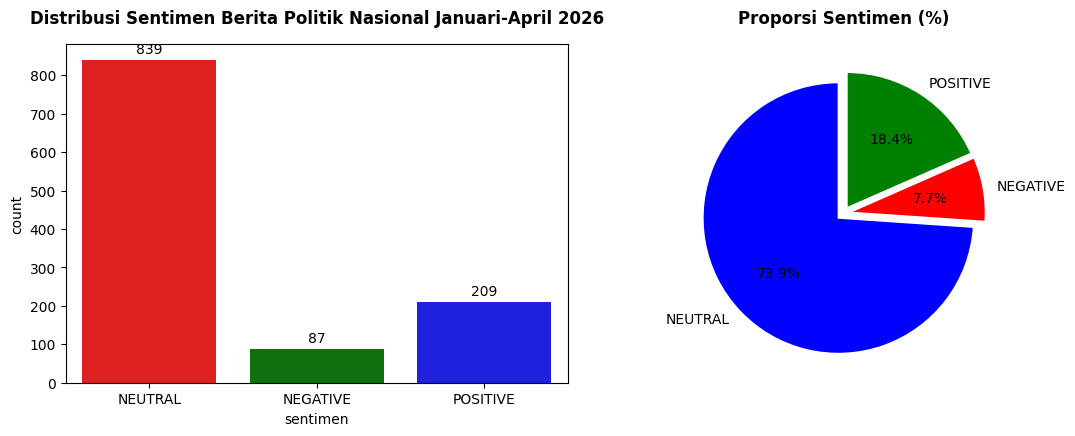

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


categories = [ 'NEUTRAL','NEGATIVE','POSITIVE']
my_colors=['blue','red','green']
color_dict = dict(zip(categories, my_colors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Card1:Bar Chart
sns.countplot(x='sentimen', data=df, ax=ax1, order=categories, palette=my_colors, hue='sentimen', legend=False)
for container in ax1.containers:
    ax1.bar_label(container, padding=3)

ax1.set_title('Distribusi Sentimen Berita Politik Nasional Januari-April 2026', pad=15, fontweight='bold')


# Card2:Pie Chat
counts = df['sentimen'].value_counts().reindex(categories)
ax2.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=my_colors,
    startangle=90,
    explode=[0.05] * len(categories),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

ax2.set_title('Proporsi Sentimen (%)', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout(pad=3.0)
plt.show()


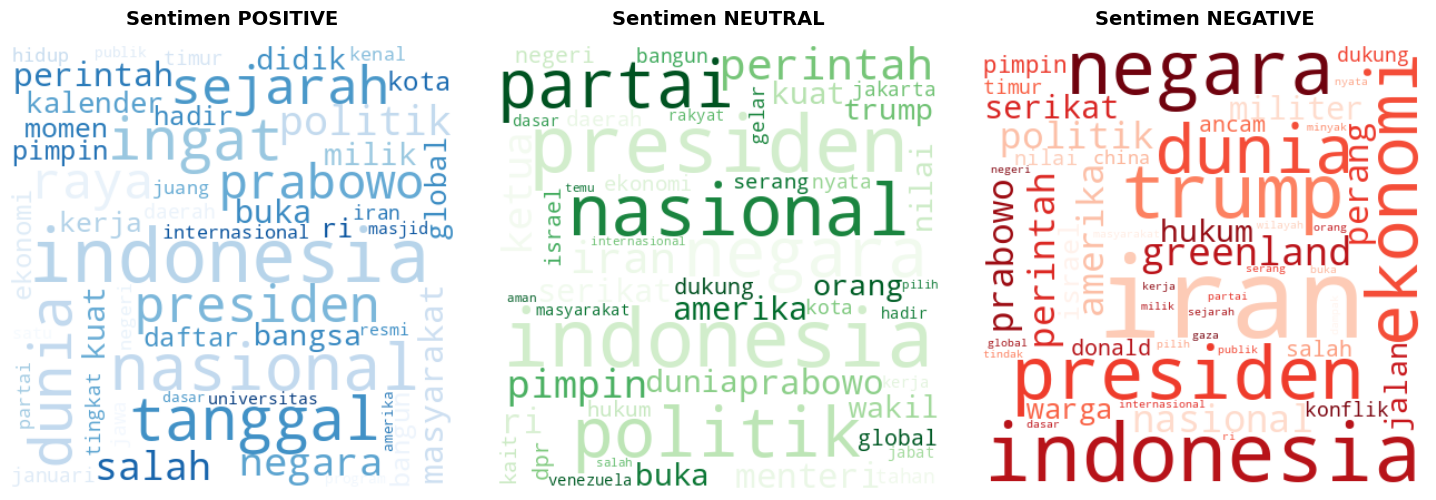

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


categories = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
color_maps = ['Blues', 'Greens', 'Reds'] 

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for i, cat in enumerate(categories):
    text_data = " ".join(df[df['sentimen'] == cat]['detokenization'].astype(str))

    # Generate WordCloud
    wc = WordCloud(
        width=400,
        height=400,
        background_color='white',
        colormap=color_maps[i],
        max_words=50,
        collocations=False 
    ).generate(text_data)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Sentimen {cat}', fontsize=14, fontweight='bold', pad=15)
    axes[i].axis("off") 

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(2)

plt.tight_layout(pad=3.0)
plt.show()

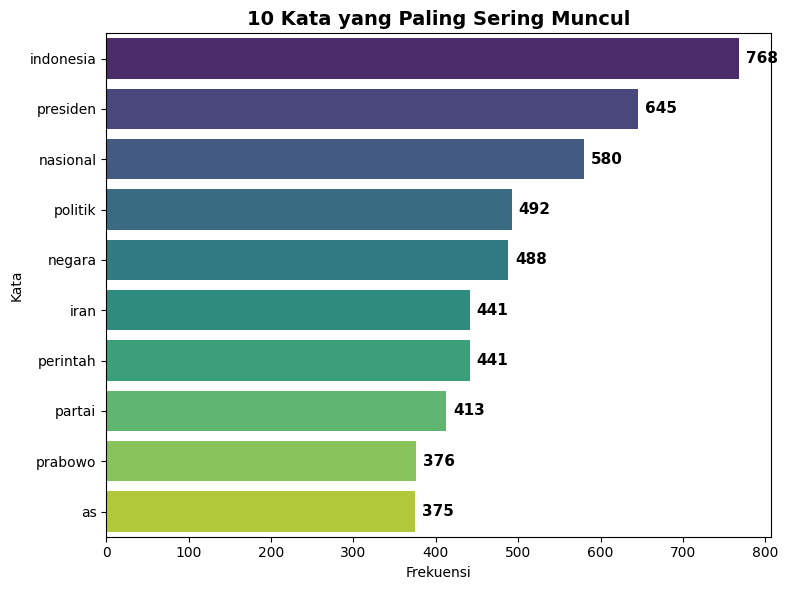

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter



semua_teks = " ".join(df['detokenization'].astype(str))

list_kata = semua_teks.split()

word_counts = Counter(list_kata)

top_10 = word_counts.most_common(10)
kata, jumlah = zip(*top_10)

plt.figure(figsize=(8, 6))

ax = sns.barplot(x=list(jumlah), y=list(kata), palette='viridis', hue=list(kata), legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title("10 Kata yang Paling Sering Muncul", fontsize=14, fontweight='bold')
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3454/86281408.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette=color)


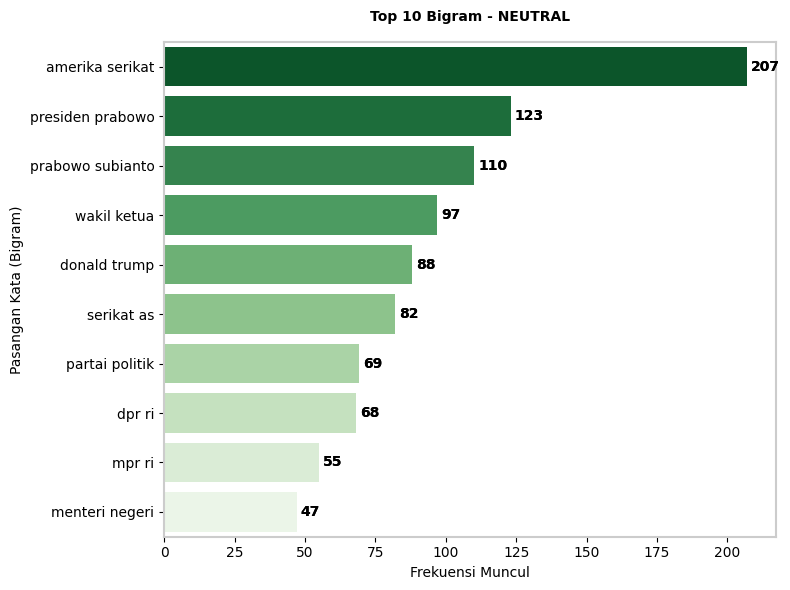

/tmp/ipykernel_3454/86281408.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette=color)


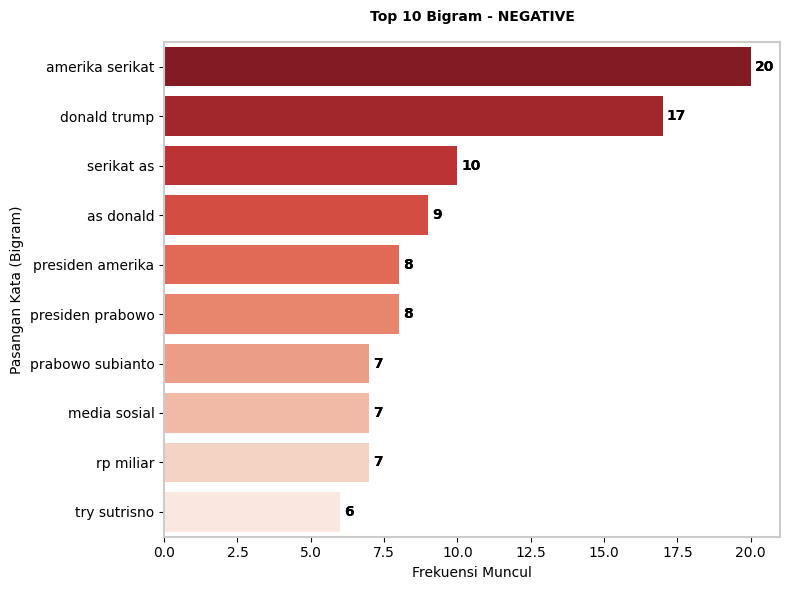

/tmp/ipykernel_3454/86281408.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette=color)


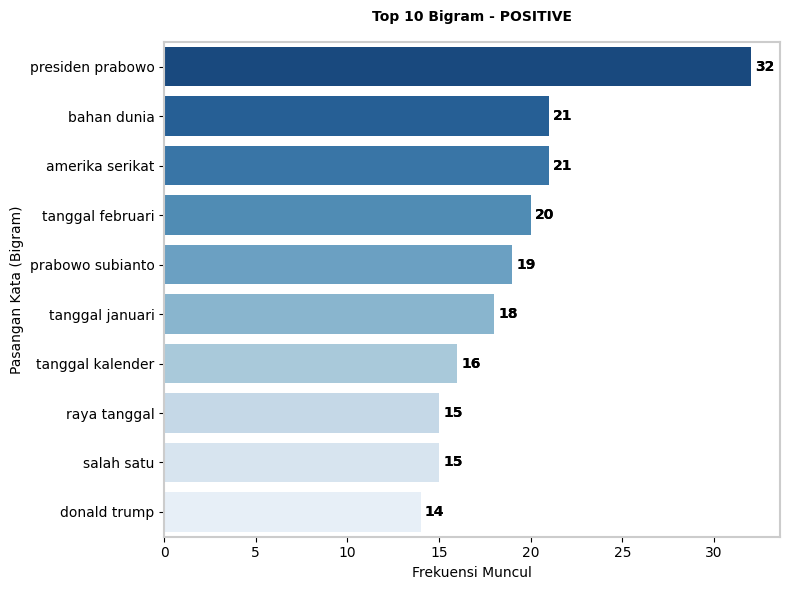

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(text, n=2, top_k=10, title="Top Bigrams", color='viridis'):
    if len(text) < 1:
        print(f"Data untuk {title} kosong.")
        return

    vec = CountVectorizer(ngram_range=(n, n)).fit(text)
    bag_of_words = vec.transform(text)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    words, counts = zip(*words_freq)

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x=list(counts), y=list(words), palette=color)


    ax = sns.barplot(x=list(counts), y=list(words), palette=color, hue=list(words), legend=False)

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    plt.title(title, fontsize=10, fontweight='bold', pad=15)
    plt.xlabel('Frekuensi Muncul')
    plt.ylabel('Pasangan Kata (Bigram)')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

# 1. Bigram NEUTRAL
neu_text = df[df['sentimen'] == 'NEUTRAL']['detokenization']
plot_top_ngrams(neu_text, n=2, title="Top 10 Bigram - NEUTRAL", color='Greens_r')

# 2. Bigram NEGATIVE
neg_text = df[df['sentimen'] == 'NEGATIVE']['detokenization']
plot_top_ngrams(neg_text, n=2, title="Top 10 Bigram - NEGATIVE", color='Reds_r')

# 3. Bigram POSITIVE
pos_text = df[df['sentimen'] == 'POSITIVE']['detokenization']
plot_top_ngrams(pos_text, n=2, title="Top 10 Bigram - POSITIVE", color='Blues_r')

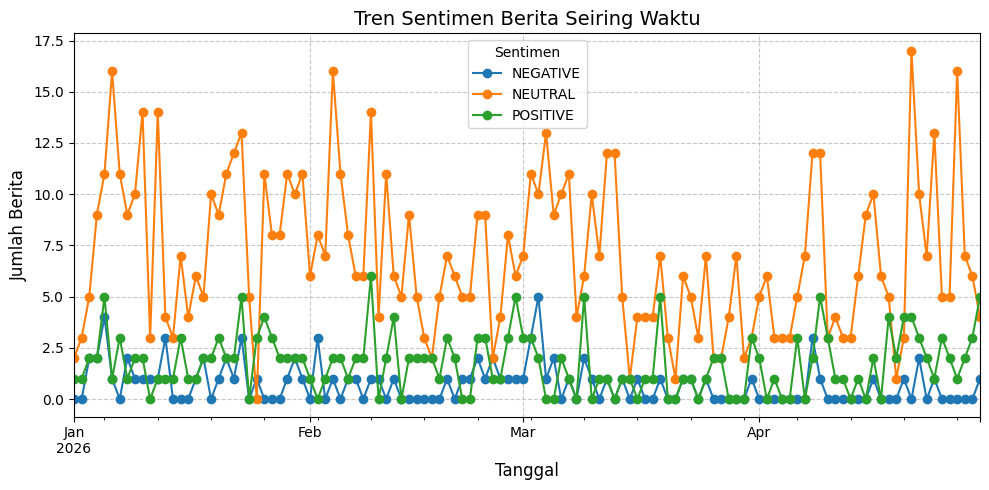

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%Y-%m-%d')

sentiment_trend = df.groupby(['Tanggal', 'sentimen']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sentiment_trend.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Tren Sentimen Berita Seiring Waktu', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)
plt.legend(title='Sentimen')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Machine Learning

#TFIDF


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#TFIDF
from sklearn.feature_extraction.text import TfidfVectorizer
# menghapus kata yang muncul kurang dari 2 kali
tfidf = TfidfVectorizer(min_df=2)

X_tfidf = tfidf.fit_transform(df['data_clean'])
len (tfidf.get_feature_names_out())

5717

#Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Mengubah data sentimen jadi numerik
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentimen'])

#Sentiment
print(label_encoder.classes_)

['NEGATIVE' 'NEUTRAL' 'POSITIVE']


In [ ]:
# Cek pemetaan label ke angka
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Label:", mapping)

Mapping Label: {'NEGATIVE': np.int64(0), 'NEUTRAL': np.int64(1), 'POSITIVE': np.int64(2)}


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
#Baseline model

#SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Inisialisasi SVM (SVC - Support Vector Classification)

model_svm = SVC(kernel='linear', random_state=42, class_weight='balanced')

# 2. Training Model
model_svm.fit(X_train, y_train)

# 3. Prediksi
y_pred_svm = model_svm.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi SVM (Support Vector Machine) ---")
print(classification_report(y_test, y_pred_svm))

# Metrik spesifik
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

--- Evaluasi SVM (Support Vector Machine) ---
              precision    recall  f1-score   support

           0       0.33      0.18      0.23        17
           1       0.84      0.87      0.85       168
           2       0.48      0.50      0.49        42

    accuracy                           0.75       227
   macro avg       0.55      0.52      0.52       227
weighted avg       0.73      0.75      0.74       227

Accuracy Score: 0.7489
F1 Score (Weighted): 0.7395


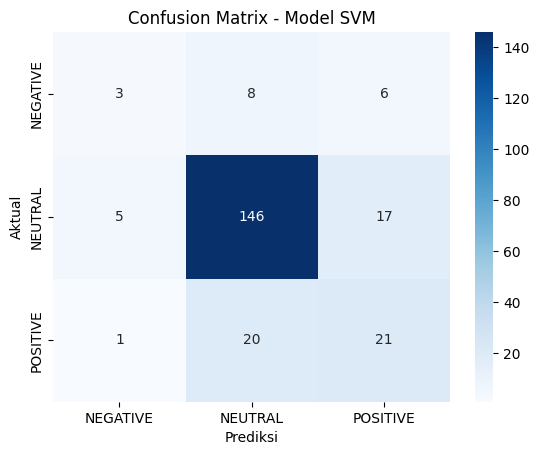

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model SVM')
plt.show()

#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score


# 1. Inisialisasi Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced' )

# 2. Training Model
model.fit(X_train, y_train)

# 3. Prediksi
y_pred = model.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi Logistic Regression ---")
print(classification_report(y_test, y_pred))

# Metrik spesifik yang kamu minta
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

--- Evaluasi Logistic Regression ---
              precision    recall  f1-score   support

           0       0.29      0.24      0.26        17
           1       0.86      0.87      0.86       168
           2       0.49      0.50      0.49        42

    accuracy                           0.75       227
   macro avg       0.54      0.53      0.54       227
weighted avg       0.75      0.75      0.75       227

Accuracy Score: 0.7533
F1 Score (Weighted): 0.7501


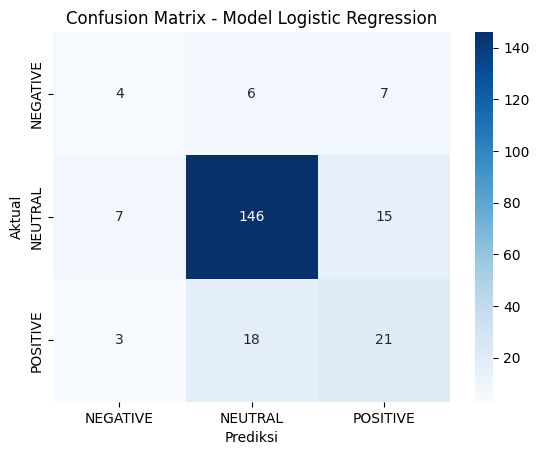

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model Logistic Regression')
plt.show()

#Balancing Data

#Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from sklearn.preprocessing import StandardScaler

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

class_counts = pd.Series(y_resampled).value_counts()
print(class_counts)

1    671
2    671
0    671
Name: count, dtype: int64


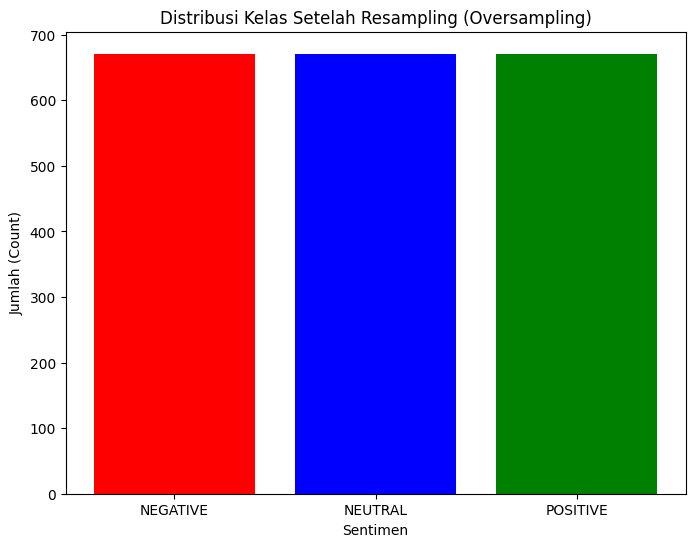

In [ ]:
import matplotlib.pyplot as plt

# Plot the class distribution
plt.figure(figsize=(8, 6))

labels = label_encoder.classes_

plt.bar(class_counts.index, class_counts.values, color=['blue', 'green', 'red'])

plt.xticks(ticks=range(len(labels)), labels=labels)

plt.xlabel('Sentimen')
plt.ylabel('Jumlah (Count)')
plt.title('Distribusi Kelas Setelah Resampling (Oversampling)')
plt.show()

In [ ]:
# Training model di resampled data
model.fit(X_resampled, y_resampled)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# 2. Training Model
model.fit(X_resampled, y_resampled)

# 3. Prediksi
y_pred_ros = model.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi ROS ---")
print(classification_report(y_test, y_pred_ros))

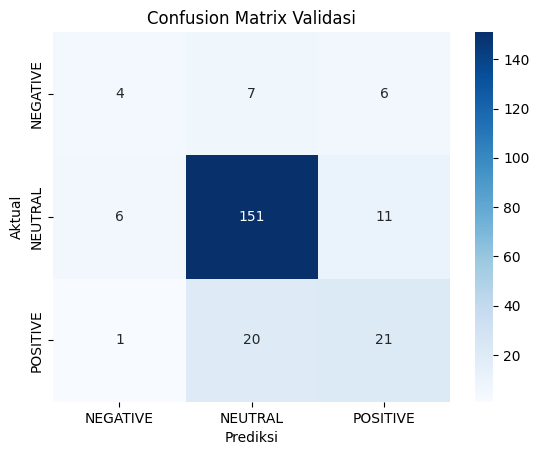

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ros)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi')
plt.show()

#Oversampling (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

class_counts = pd.Series(y_resampled).value_counts()
print(class_counts)

1    671
2    671
0    671
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# 2. Training Model
model.fit(X_resampled, y_resampled)

# 3. Prediksi
y_pred_smote = model.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi SMOTE ---")
print(classification_report(y_test, y_pred_smote))

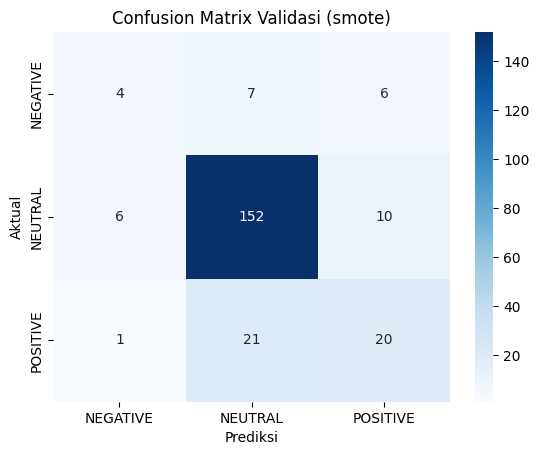

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi (smote)')
plt.show()

#Oversampling ADASYN

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
import pandas as pd


scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

# 2. Menjalankan ADASYN
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled, y_train)

In [ ]:
# 3. Cek hasil 
class_counts_ada = pd.Series(y_resampled).value_counts()
print("Jumlah kelas setelah ADASYN & Scaling:")
print(class_counts_ada)

Jumlah kelas setelah ADASYN & Scaling:
0    692
1    671
2    632
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_final = LogisticRegression(max_iter=1000, random_state=42)
model_final.fit(X_resampled, y_resampled)


y_pred_ada = model_final.predict(X_test_scaled)

print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.29      0.12      0.17        17
           1       0.80      0.92      0.86       168
           2       0.56      0.36      0.43        42

    accuracy                           0.76       227
   macro avg       0.55      0.47      0.49       227
weighted avg       0.72      0.76      0.73       227



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix ADASYN')
plt.show()

#Undersampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# Inisialisasi
undersample = RandomUnderSampler(random_state=42)

# Fit & Resample pada data training
X_resampled_under, y_resampled_under = undersample.fit_resample(X_train, y_train)

# Cek jumlahnya
class_counts_under = pd.Series(y_resampled_under).value_counts().sort_index()
print("Jumlah data setelah Undersampling:")
print(class_counts_under)

Jumlah data setelah Undersampling:
0    70
1    70
2    70
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Inisialisasi model
model_under = LogisticRegression(max_iter=1000, random_state=42)

# 2. Latih model 
model_under.fit(X_resampled_under, y_resampled_under)

# 3. Prediksi 
y_pred_under = model_under.predict(X_test)

print(classification_report(y_test, y_pred_under))

              precision    recall  f1-score   support

           0       0.14      0.47      0.22        17
           1       0.87      0.54      0.67       168
           2       0.41      0.64      0.50        42

    accuracy                           0.56       227
   macro avg       0.47      0.55      0.46       227
weighted avg       0.73      0.56      0.60       227



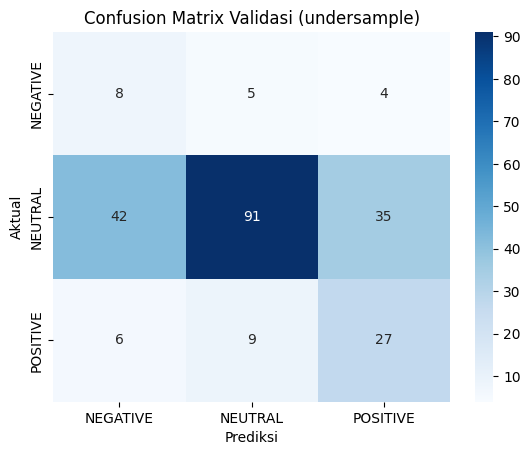

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_under)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi (undersample)')
plt.show()

#EditedNearestNeighbours

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours
import pandas as pd

# 1. Inisialisasi ENN
enn = EditedNearestNeighbours()

# 2. Fit & Resample
X_resampled_enn, y_resampled_enn = enn.fit_resample(X_train, y_train)

# 3. Cek hasil 
class_counts_enn = pd.Series(y_resampled_enn).value_counts().sort_index()
print("Jumlah data setelah dibersihkan dengan ENN:")
print(class_counts_enn)

Jumlah data setelah dibersihkan dengan ENN:
0     70
1    393
2     22
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Latih model 
model_enn = LogisticRegression(max_iter=1000, random_state=42)
model_enn.fit(X_resampled_enn, y_resampled_enn)

# Prediksi
y_pred_enn = model_enn.predict(X_test)

print("\n--- Laporan Klasifikasi: ENN ---")
print(classification_report(y_test, y_pred_enn))


--- Laporan Klasifikasi: ENN ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.75      1.00      0.86       168
           2       1.00      0.07      0.13        42

    accuracy                           0.75       227
   macro avg       0.58      0.36      0.33       227
weighted avg       0.74      0.75      0.66       227



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


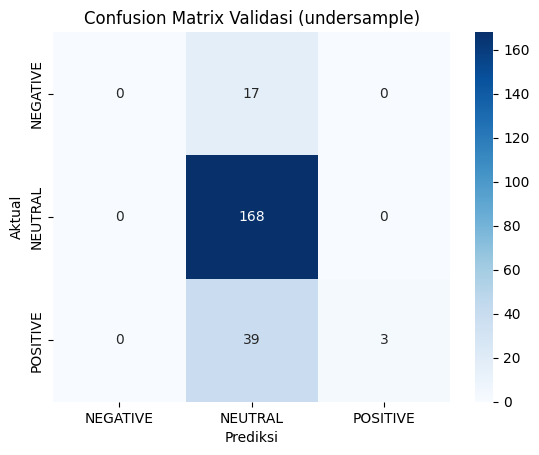

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_enn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi (undersample)')
plt.show()